In [1]:
# Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings("ignore",category=FutureWarning)
warnings.filterwarnings("ignore")
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
pd.set_option("display.max_rows",100)

In [2]:
train=pd.read_csv(r"D:\Artificial_Intelligence\AI\Supervised_Learning\6_Linear_Regression_Problemns\1_Problem\HousePrices\train.csv")
test=pd.read_csv(r"D:\Artificial_Intelligence\AI\Supervised_Learning\6_Linear_Regression_Problemns\1_Problem\HousePrices\test.csv")

## STEP 1 EDA

In [3]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
train.shape

(1460, 81)

In [5]:
train.isna().sum()

Id                  0
MSSubClass          0
MSZoning            0
LotFrontage       259
LotArea             0
Street              0
Alley            1369
LotShape            0
LandContour         0
Utilities           0
LotConfig           0
LandSlope           0
Neighborhood        0
Condition1          0
Condition2          0
BldgType            0
HouseStyle          0
OverallQual         0
OverallCond         0
YearBuilt           0
YearRemodAdd        0
RoofStyle           0
RoofMatl            0
Exterior1st         0
Exterior2nd         0
MasVnrType          8
MasVnrArea          8
ExterQual           0
ExterCond           0
Foundation          0
BsmtQual           37
BsmtCond           37
BsmtExposure       38
BsmtFinType1       37
BsmtFinSF1          0
BsmtFinType2       38
BsmtFinSF2          0
BsmtUnfSF           0
TotalBsmtSF         0
Heating             0
HeatingQC           0
CentralAir          0
Electrical          1
1stFlrSF            0
2ndFlrSF            0
LowQualFin

In [6]:
for i in train.columns:
    if train[i].isna().sum()>0:
        print(i)

LotFrontage
Alley
MasVnrType
MasVnrArea
BsmtQual
BsmtCond
BsmtExposure
BsmtFinType1
BsmtFinType2
Electrical
FireplaceQu
GarageType
GarageYrBlt
GarageFinish
GarageQual
GarageCond
PoolQC
Fence
MiscFeature


In [7]:
# Second method to find null value
[i for i in train.columns if train[i].isna().sum()>0 ]

['LotFrontage',
 'Alley',
 'MasVnrType',
 'MasVnrArea',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Electrical',
 'FireplaceQu',
 'GarageType',
 'GarageYrBlt',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PoolQC',
 'Fence',
 'MiscFeature']

In [8]:
train['LotFrontage'].shape

(1460,)

In [9]:
# First method to find columns have null value grater than 30%
for i in train.columns:
    if train[i].isna().sum()>0:
        if ((train[i].isna().sum()/train[i].shape)*100)>30:
            print(i)

Alley
FireplaceQu
PoolQC
Fence
MiscFeature


In [10]:
# second method to find columns have null value grater than 30%
[i for i in train.columns if train[i].isna().sum()>0 if ((train[i].isna().sum()/train[i].shape)*100)>30]
        
    

['Alley', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature']

In [11]:
# Drop ṭhe null value columns
train.drop(['Alley', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature'],axis=1,inplace=True)

In [12]:
train_null_coiumns=[i for i in train.columns if train[i].isna().sum()>0 ]

In [13]:
train_null_coiumns

['LotFrontage',
 'MasVnrType',
 'MasVnrArea',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Electrical',
 'GarageType',
 'GarageYrBlt',
 'GarageFinish',
 'GarageQual',
 'GarageCond']

In [14]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 76 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

In [15]:
for i in train_null_coiumns:
    if train[i].dtype=="object":
        print(i)
    else:
        print(i, "---this is numerical")

LotFrontage ---this is numerical
MasVnrType
MasVnrArea ---this is numerical
BsmtQual
BsmtCond
BsmtExposure
BsmtFinType1
BsmtFinType2
Electrical
GarageType
GarageYrBlt ---this is numerical
GarageFinish
GarageQual
GarageCond


In [16]:
# drop the ID columns
train.drop("Id",axis=1,inplace=True)

In [17]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 75 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   LotShape       1460 non-null   object 
 6   LandContour    1460 non-null   object 
 7   Utilities      1460 non-null   object 
 8   LotConfig      1460 non-null   object 
 9   LandSlope      1460 non-null   object 
 10  Neighborhood   1460 non-null   object 
 11  Condition1     1460 non-null   object 
 12  Condition2     1460 non-null   object 
 13  BldgType       1460 non-null   object 
 14  HouseStyle     1460 non-null   object 
 15  OverallQual    1460 non-null   int64  
 16  OverallCond    1460 non-null   int64  
 17  YearBuilt      1460 non-null   int64  
 18  YearRemo

In [18]:
# select numerical columns
numerical_columns=train.select_dtypes(include=np.number).columns
numerical_columns

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

In [19]:
# select object columns
object_columns=train.select_dtypes(include=np.object).columns
object_columns

Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
       'PavedDrive', 'SaleType', 'SaleCondition'],
      dtype='object')

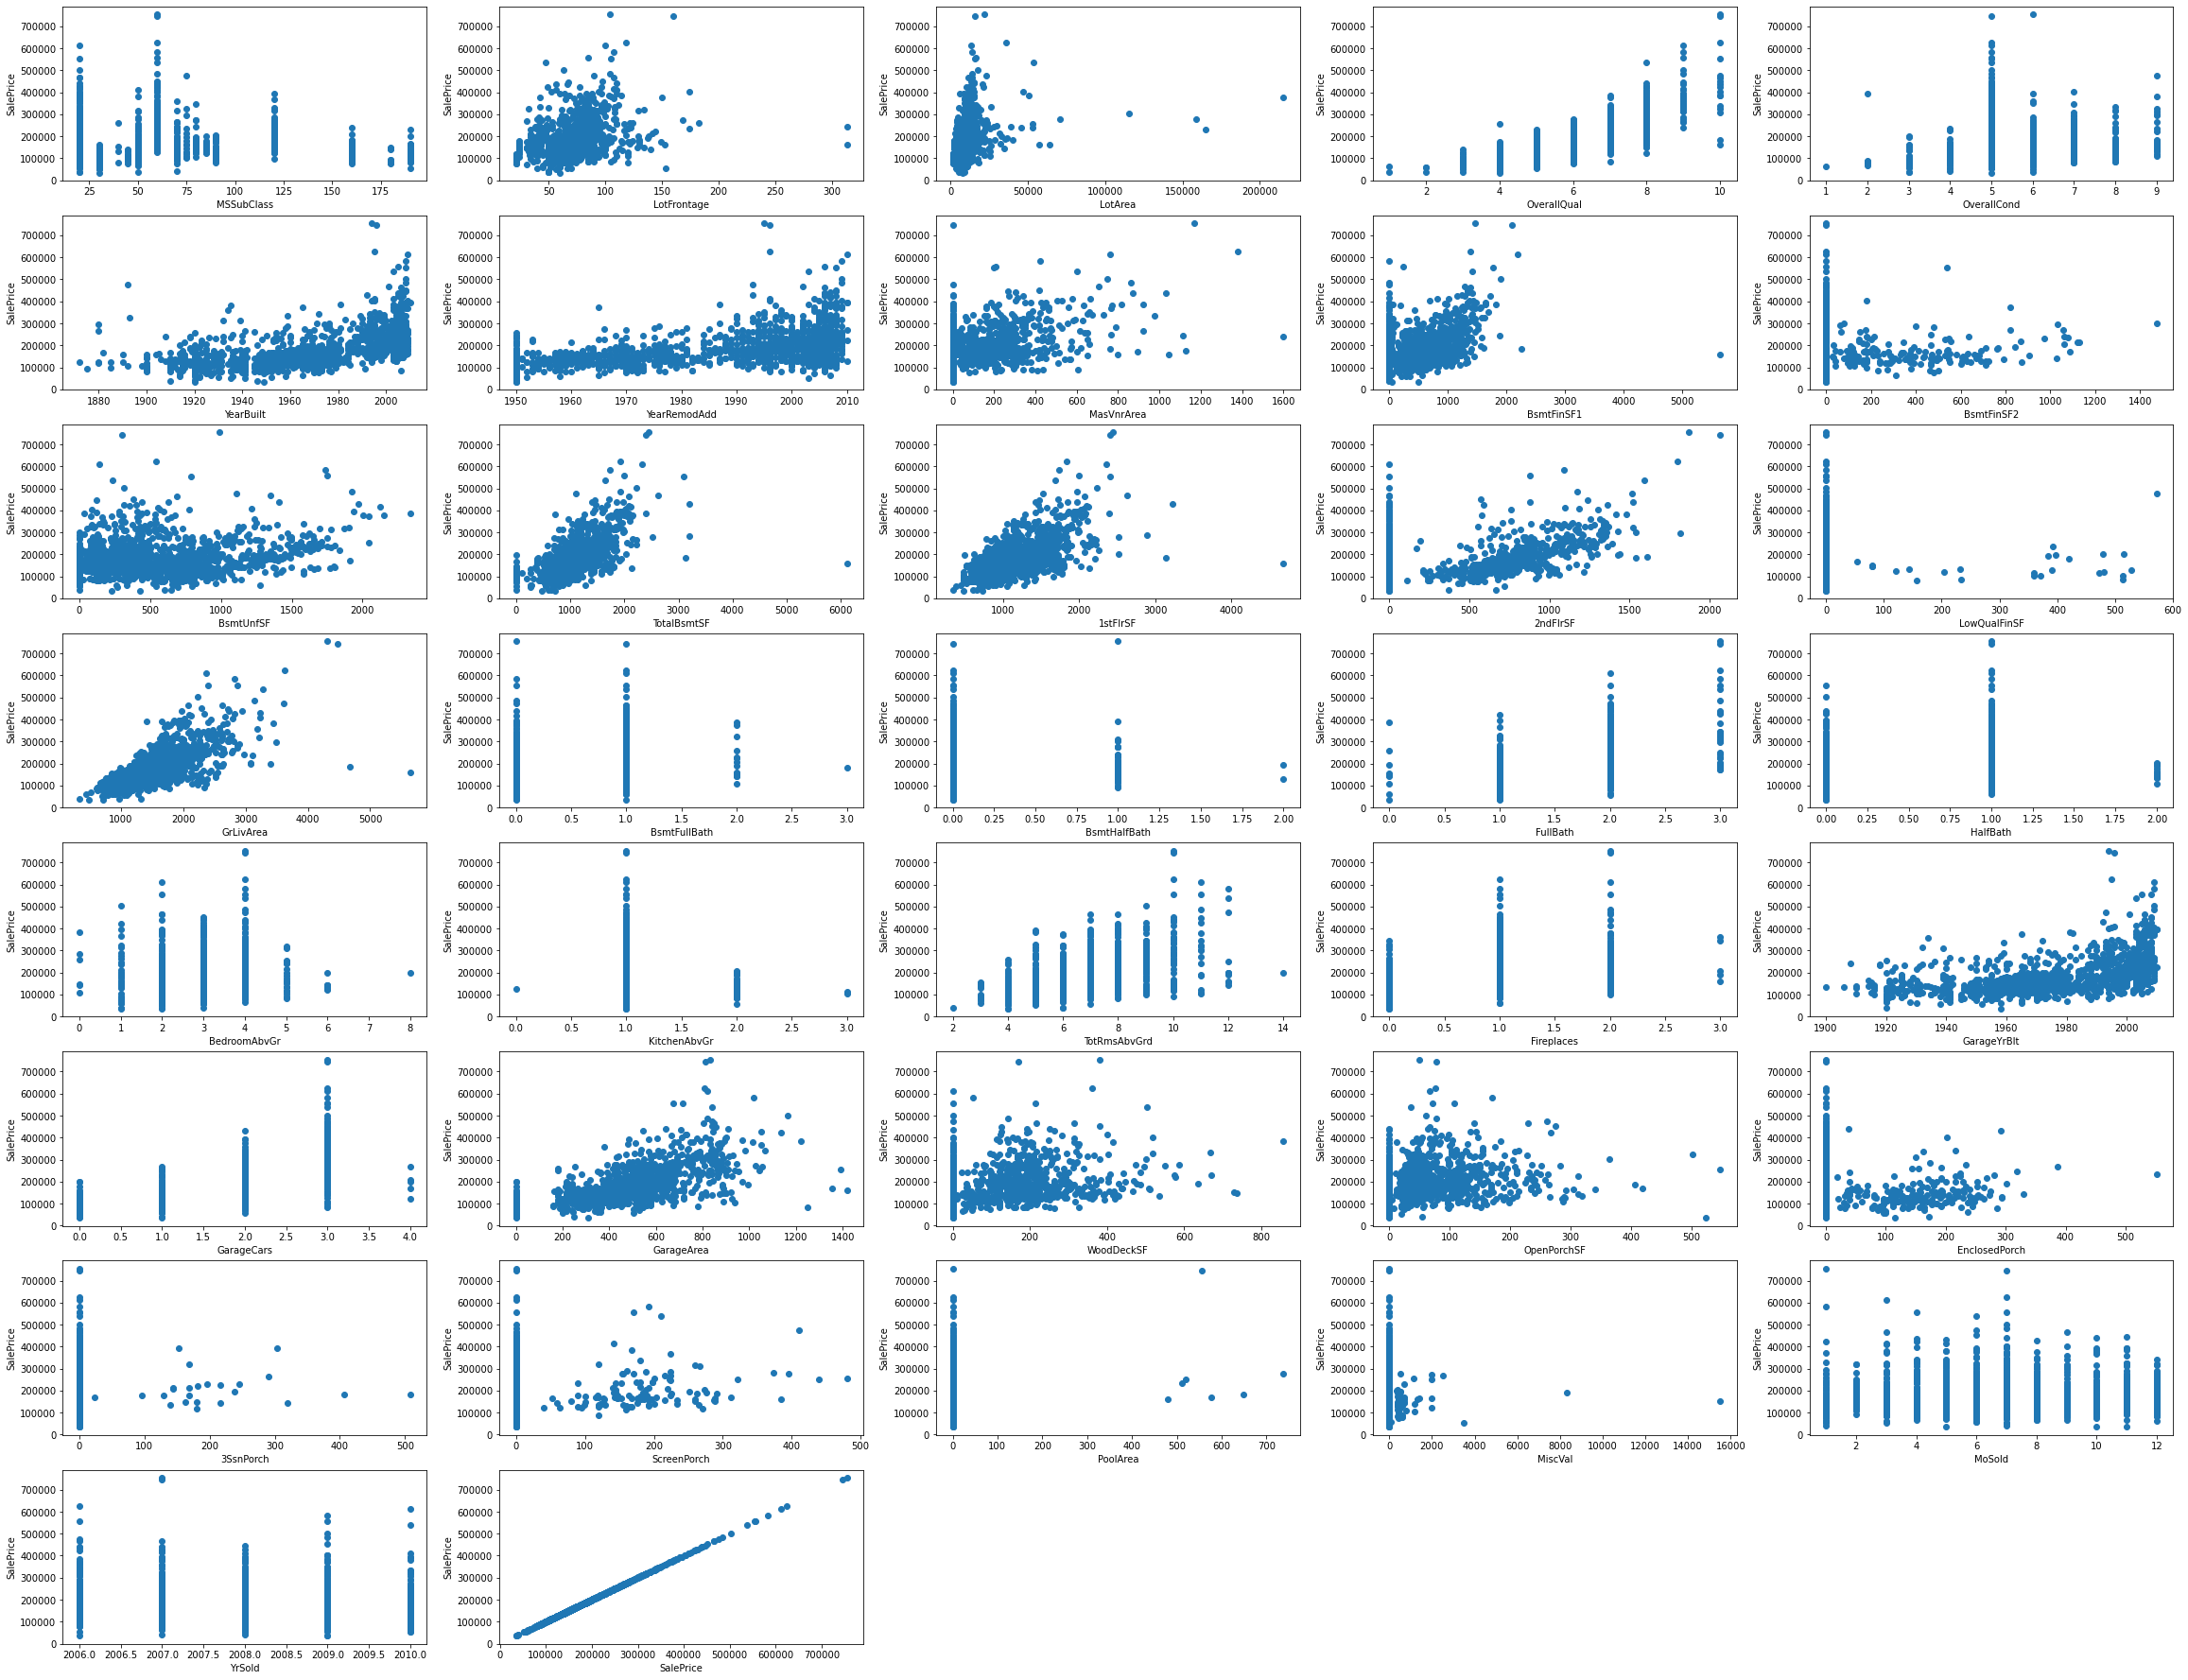

In [20]:
y=0
plt.figure(figsize=(40,40))
for j in numerical_columns:
    plt.subplot(10,5,y+1)
    plt.xlabel(j)
    plt.ylabel("SalePrice")
    plt.scatter(train[j],train['SalePrice'])
    y+=1

In [21]:
train["MSSubClass"].nunique()

15

In [22]:
discrete=[]
continuous=[]
for i in numerical_columns:
    if train[i].nunique()>20:
        continuous.append(i)
    else:
        discrete.append(i)

In [23]:
discrete

['MSSubClass',
 'OverallQual',
 'OverallCond',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageCars',
 '3SsnPorch',
 'PoolArea',
 'MoSold',
 'YrSold']

In [24]:
continuous

['LotFrontage',
 'LotArea',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'GarageYrBlt',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 'ScreenPorch',
 'MiscVal',
 'SalePrice']

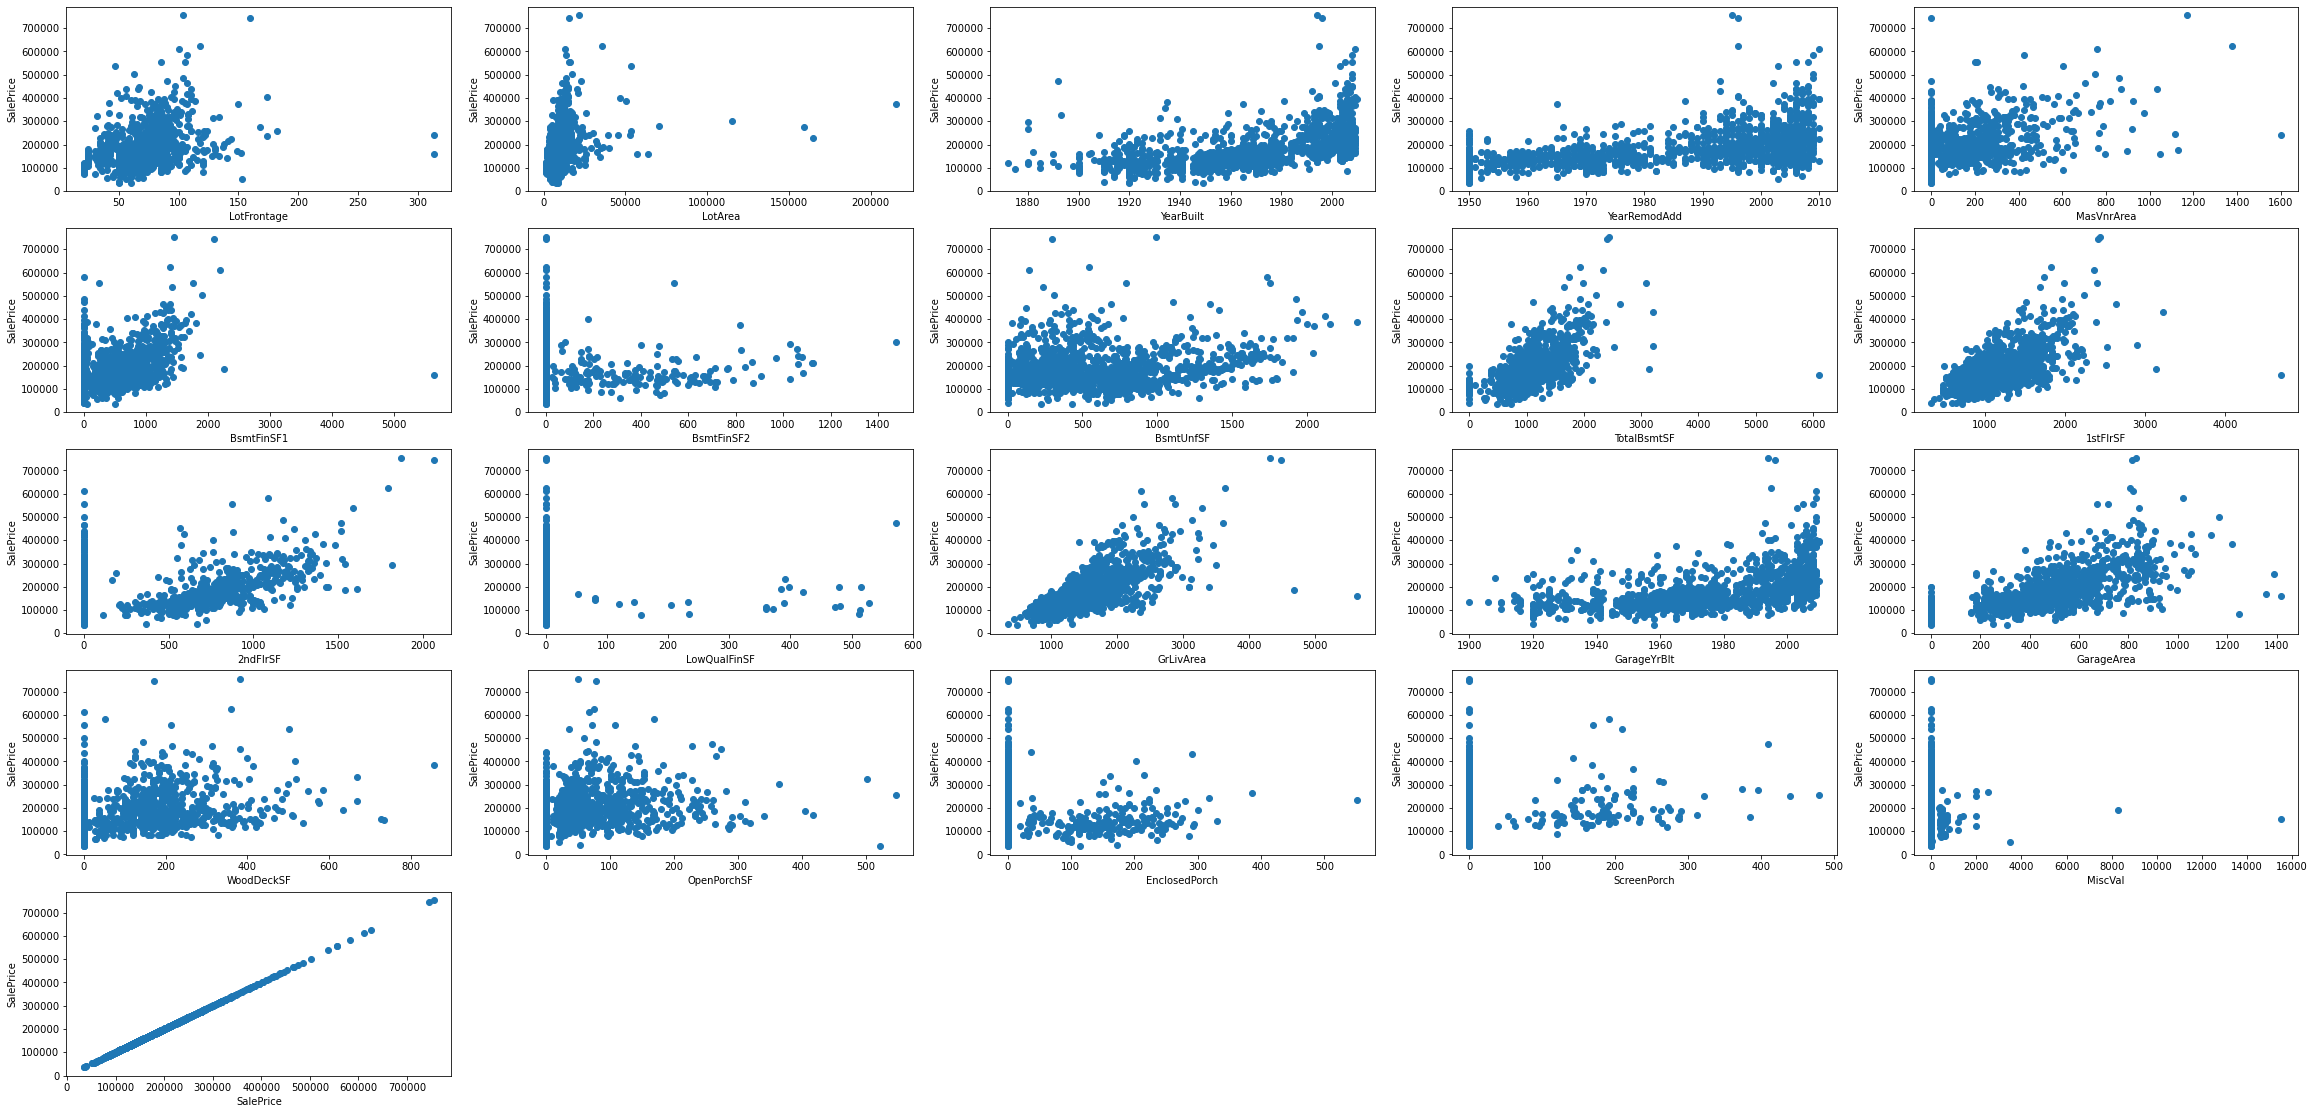

In [25]:
y=0
plt.figure(figsize=(40,40))
for j in continuous:
    plt.subplot(10,5,y+1)
    plt.xlabel(j)
    plt.ylabel("SalePrice")
    plt.scatter(train[j],train['SalePrice'])
    y+=1

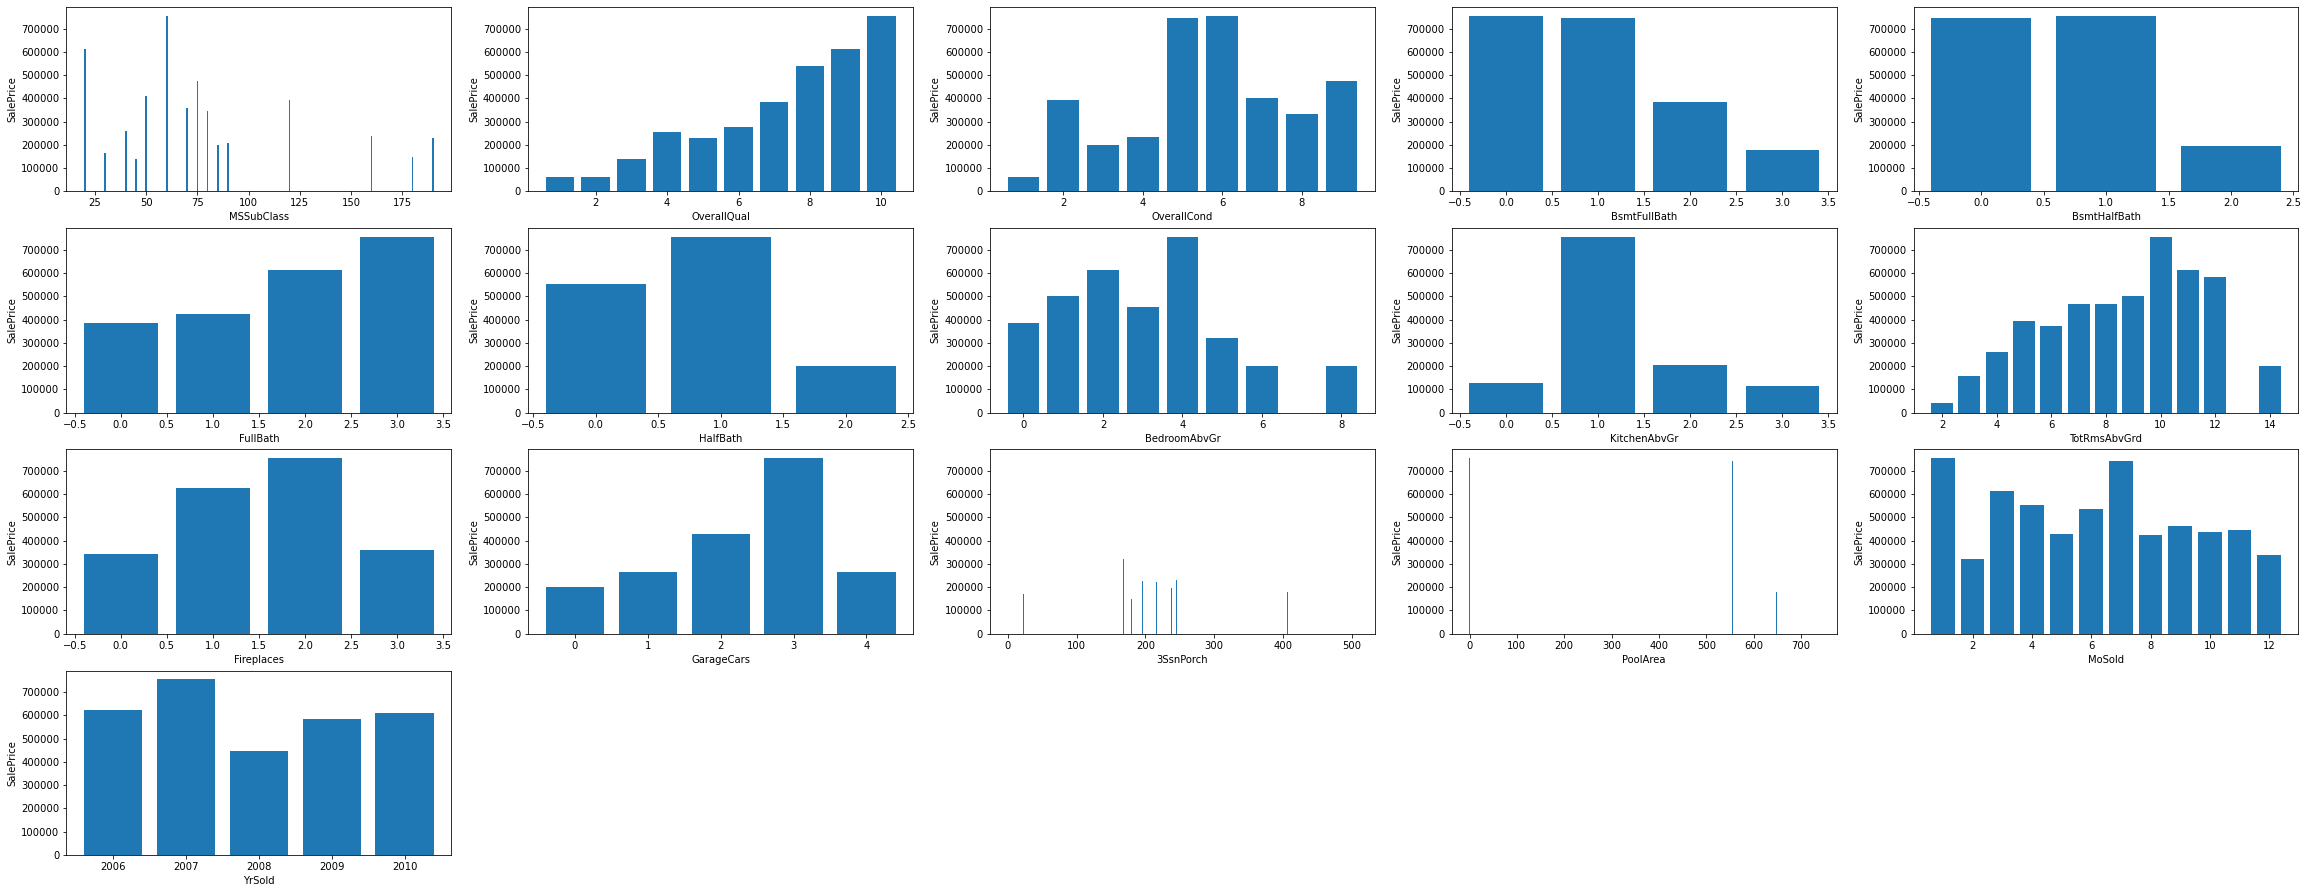

In [26]:
y=0
plt.figure(figsize=(40,40))
for j in discrete:
    plt.subplot(10,5,y+1)
    plt.xlabel(j)
    plt.ylabel("SalePrice")
    plt.bar(train[j],train['SalePrice'])
    y+=1

In [27]:
train['LotFrontage']

0       65.0
1       80.0
2       68.0
3       60.0
4       84.0
        ... 
1455    62.0
1456    85.0
1457    66.0
1458    68.0
1459    75.0
Name: LotFrontage, Length: 1460, dtype: float64

In [28]:
## Handling outliers 
continuous

['LotFrontage',
 'LotArea',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'GarageYrBlt',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 'ScreenPorch',
 'MiscVal',
 'SalePrice']

In [29]:
train.shape

(1460, 75)

In [30]:
# upper_lim=train['LotFrontage'].mean()+train['LotFrontage'].std() *3
# lower_lim=train['LotFrontage'].mean()-train['LotFrontage'].std() *3

# train.loc[(train['LotFrontage'] >upper_lim),'LotFrontage'] = upper_lim
# train.loc[(train['LotFrontage'] < lower_lim),'LotFrontage'] = lower_lim

 


upper_lim=train['LotFrontage'].mean()+train['LotFrontage'].std() *3
lower_lim=train['LotFrontage'].mean()-train['LotFrontage'].std() *3
train.loc[(train['LotFrontage'] >upper_lim),'LotFrontage']=upper_lim
train.loc[(train['LotFrontage'] <lower_lim),'LotFrontage']=lower_lim



In [31]:
train['LotFrontage']

0       65.0
1       80.0
2       68.0
3       60.0
4       84.0
        ... 
1455    62.0
1456    85.0
1457    66.0
1458    68.0
1459    75.0
Name: LotFrontage, Length: 1460, dtype: float64

In [32]:
upper_lim

142.9042136914762

In [33]:
lower_lim

-2.804296955422899

In [34]:
train['LotFrontage']

0       65.0
1       80.0
2       68.0
3       60.0
4       84.0
        ... 
1455    62.0
1456    85.0
1457    66.0
1458    68.0
1459    75.0
Name: LotFrontage, Length: 1460, dtype: float64

In [35]:
for i in continuous:
    upper_lim=train[i].mean()+train[i].std() *3
    lower_lim=train[i].mean()-train[i].std() *3

    train.loc[(train[i] >upper_lim),i]=upper_lim
    train.loc[(train[i] <lower_lim),i]=lower_lim

In [36]:
train['LotFrontage']

0       65.0
1       80.0
2       68.0
3       60.0
4       84.0
        ... 
1455    62.0
1456    85.0
1457    66.0
1458    68.0
1459    75.0
Name: LotFrontage, Length: 1460, dtype: float64

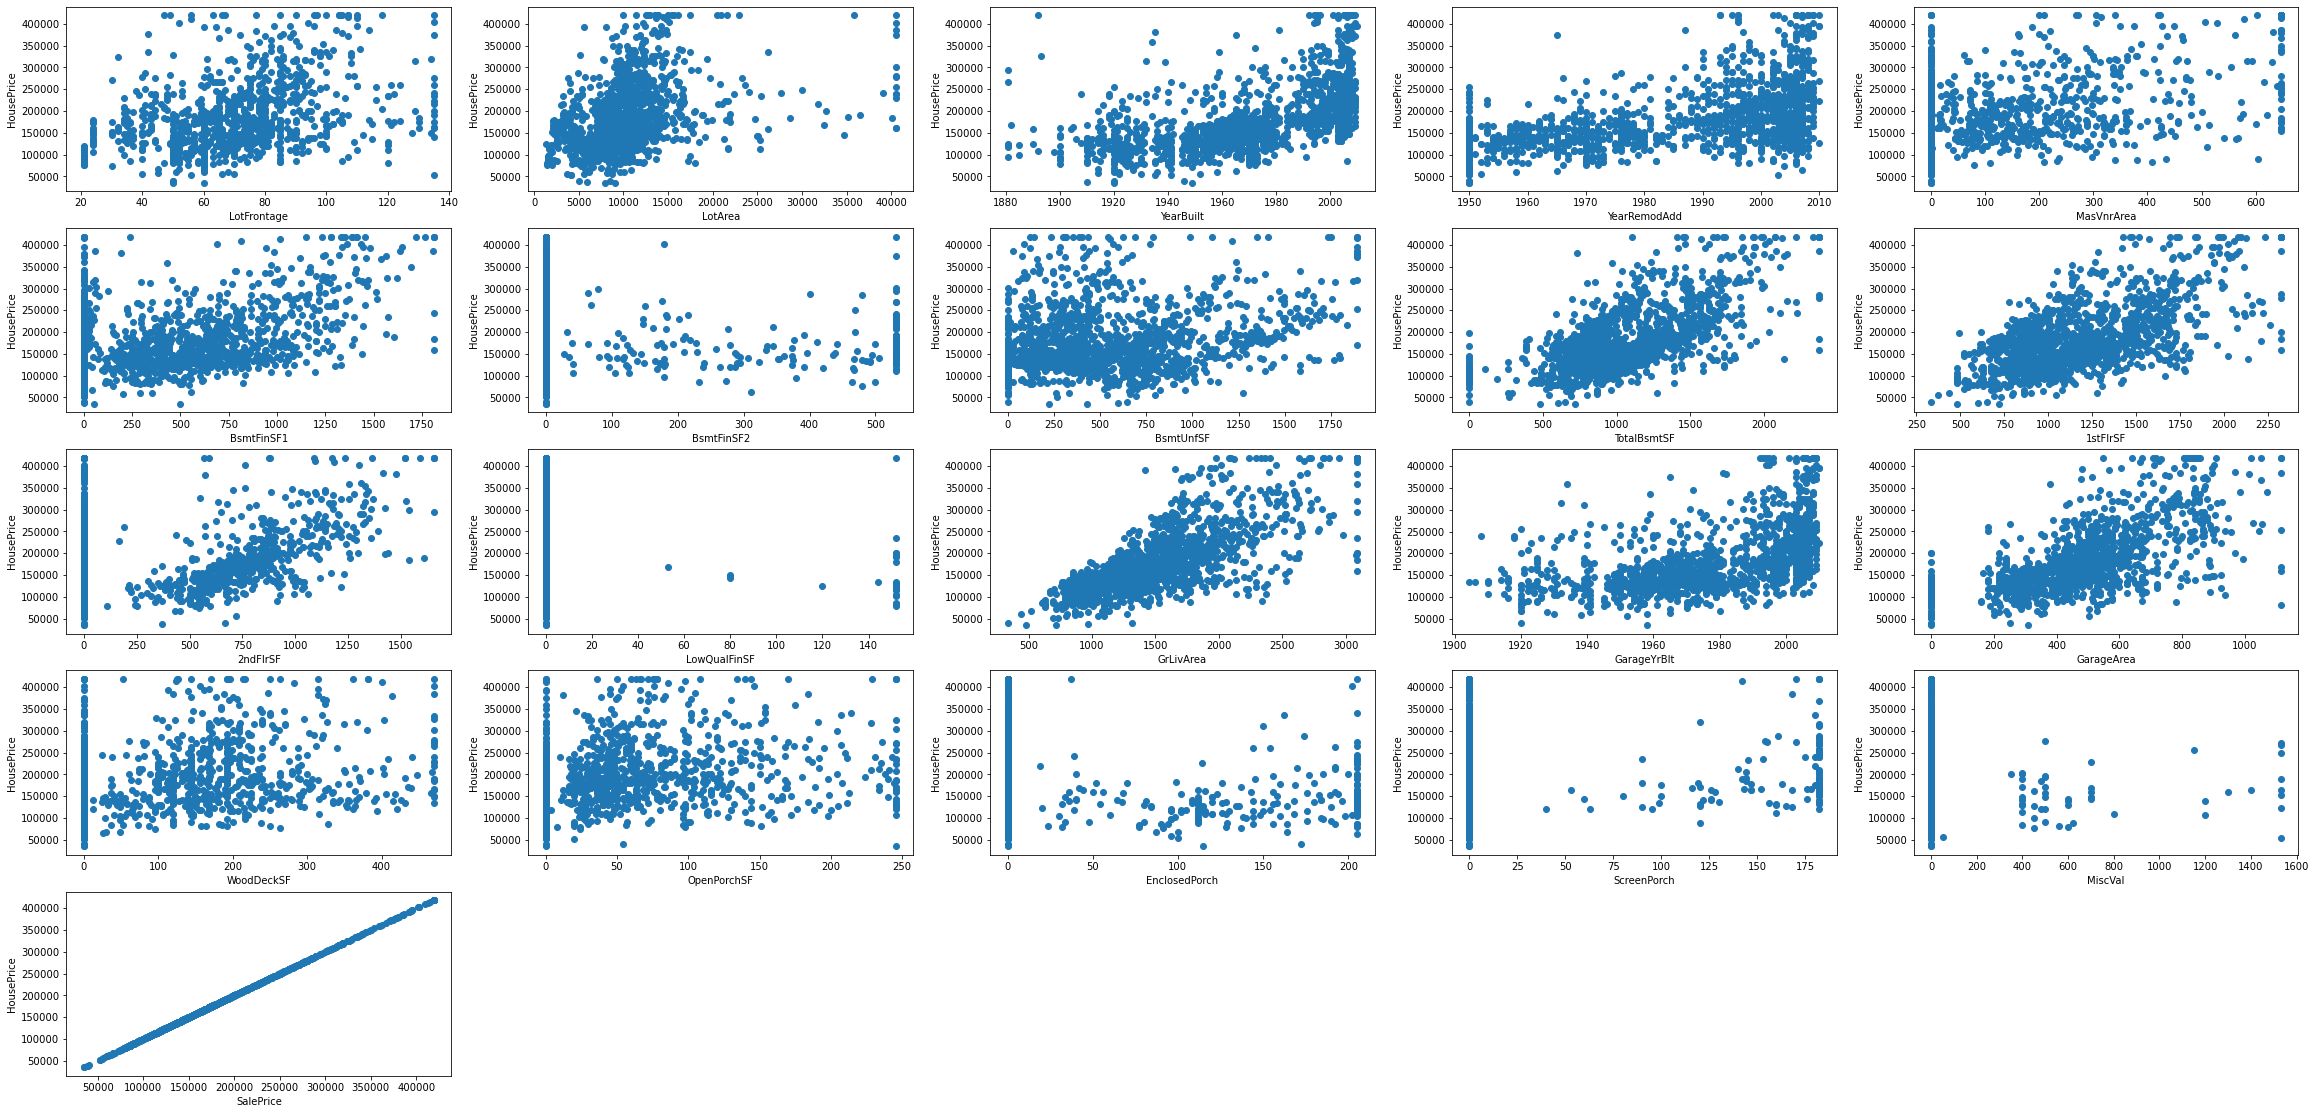

In [37]:
j=0
plt.figure(figsize=(40,40))
for column in continuous:
    plt.subplot(10,5,j+1)
    plt.scatter(train[column],train['SalePrice'])
    plt.xlabel(column)
    plt.ylabel("HousePrice")
    j+=1

In [38]:
object_columns

Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
       'PavedDrive', 'SaleType', 'SaleCondition'],
      dtype='object')

In [39]:
lr=LabelEncoder()


    

In [40]:
for i in object_columns:
    train[i]=lr.fit_transform(train[i])

In [41]:
train

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,3,65.0,8450.0,1,3,3,0,4,0,...,0.000000,0,0.0,0,0.000000,2,2008,8,4,208500.0
1,20,3,80.0,9600.0,1,3,3,0,2,0,...,0.000000,0,0.0,0,0.000000,5,2007,8,4,181500.0
2,60,3,68.0,11250.0,1,0,3,0,4,0,...,0.000000,0,0.0,0,0.000000,9,2008,8,4,223500.0
3,70,3,60.0,9550.0,1,0,3,0,0,0,...,205.311555,0,0.0,0,0.000000,2,2006,8,0,140000.0
4,60,3,84.0,14260.0,1,0,3,0,2,0,...,0.000000,0,0.0,0,0.000000,12,2008,8,4,250000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,3,62.0,7917.0,1,3,3,0,4,0,...,0.000000,0,0.0,0,0.000000,8,2007,8,4,175000.0
1456,20,3,85.0,13175.0,1,3,3,0,4,0,...,0.000000,0,0.0,0,0.000000,2,2010,8,4,210000.0
1457,70,3,66.0,9042.0,1,3,3,0,4,0,...,0.000000,0,0.0,0,1531.858114,5,2010,8,4,266500.0
1458,20,3,68.0,9717.0,1,3,3,0,4,0,...,112.000000,0,0.0,0,0.000000,4,2010,8,4,142125.0


In [42]:
corr_df=train.corr()

In [43]:
corr_df

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
MSSubClass,1.000000,0.035900,-0.428990,-0.279702,-0.024969,0.119289,-0.002940,-0.022844,0.075910,-0.025672,...,-0.019256,-0.043825,-0.029757,0.008283,-0.018792,-0.013585,-0.021407,0.012464,-0.024940,-0.088248
MSZoning,0.035900,1.000000,-0.125979,-0.062106,0.087654,0.061887,-0.017854,-0.001192,-0.009895,-0.022055,...,0.120375,0.000362,0.012400,-0.003128,0.020830,-0.031496,-0.020628,0.097437,0.009494,-0.180951
LotFrontage,-0.428990,-0.125979,1.000000,0.559219,-0.047776,-0.178282,-0.041365,NaN,-0.214139,0.064437,...,-0.015148,0.081780,0.051472,0.115645,0.009229,0.012829,0.008242,-0.036465,0.070055,0.381047
LotArea,-0.279702,-0.062106,0.559219,1.000000,-0.127256,-0.261656,-0.154051,0.021477,-0.174378,0.336976,...,-0.023979,0.048513,0.086772,0.117284,0.053330,-0.004737,-0.034066,0.001833,0.045476,0.381589
Street,-0.024969,0.087654,-0.047776,-0.127256,1.000000,-0.010224,0.115995,0.001682,0.013960,-0.179360,...,0.024102,0.007473,-0.026098,0.004413,-0.078932,0.003690,-0.025043,0.014339,0.006064,0.043274
LotShape,0.119289,0.061887,-0.178282,-0.261656,-0.010224,1.000000,0.085434,-0.036101,0.221102,-0.099951,...,0.091565,-0.036459,-0.048766,-0.020051,-0.019515,-0.033455,0.036449,-0.000911,-0.038118,-0.261493
LandContour,-0.002940,-0.017854,-0.041365,-0.154051,0.115995,0.085434,1.000000,0.008238,-0.025527,-0.374267,...,-0.056298,-0.021404,-0.000806,-0.013098,0.030977,-0.011599,0.020507,-0.025754,0.033809,0.014364
Utilities,-0.022844,-0.001192,NaN,0.021477,0.001682,-0.036101,0.008238,1.000000,-0.032589,-0.005909,...,-0.009823,-0.003046,0.101348,-0.001798,-0.004332,-0.051552,0.023353,-0.126770,-0.089701,-0.015023
LotConfig,0.075910,-0.009895,-0.214139,-0.174378,0.013960,0.221102,-0.025527,-0.032589,1.000000,-0.007256,...,-0.062277,-0.030479,0.001258,-0.046798,-0.007855,0.018902,-0.005992,0.014325,0.051579,-0.061278
LandSlope,-0.025672,-0.022055,0.064437,0.336976,-0.179360,-0.099951,-0.374267,-0.005909,-0.007256,1.000000,...,-0.007796,0.008694,0.054274,-0.015505,0.014033,0.007072,-0.002305,0.054858,-0.043095,0.055804


In [44]:
x=train.drop("SalePrice",axis=1)
y=train["SalePrice"]

In [45]:
x

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,60,3,65.0,8450.0,1,3,3,0,4,0,...,61.0,0.000000,0,0.0,0,0.000000,2,2008,8,4
1,20,3,80.0,9600.0,1,3,3,0,2,0,...,0.0,0.000000,0,0.0,0,0.000000,5,2007,8,4
2,60,3,68.0,11250.0,1,0,3,0,4,0,...,42.0,0.000000,0,0.0,0,0.000000,9,2008,8,4
3,70,3,60.0,9550.0,1,0,3,0,0,0,...,35.0,205.311555,0,0.0,0,0.000000,2,2006,8,0
4,60,3,84.0,14260.0,1,0,3,0,2,0,...,84.0,0.000000,0,0.0,0,0.000000,12,2008,8,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,3,62.0,7917.0,1,3,3,0,4,0,...,40.0,0.000000,0,0.0,0,0.000000,8,2007,8,4
1456,20,3,85.0,13175.0,1,3,3,0,4,0,...,0.0,0.000000,0,0.0,0,0.000000,2,2010,8,4
1457,70,3,66.0,9042.0,1,3,3,0,4,0,...,60.0,0.000000,0,0.0,0,1531.858114,5,2010,8,4
1458,20,3,68.0,9717.0,1,3,3,0,4,0,...,0.0,112.000000,0,0.0,0,0.000000,4,2010,8,4


In [46]:
y

0       208500.0
1       181500.0
2       223500.0
3       140000.0
4       250000.0
          ...   
1455    175000.0
1456    210000.0
1457    266500.0
1458    142125.0
1459    147500.0
Name: SalePrice, Length: 1460, dtype: float64

In [47]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=0)

In [48]:
X_train.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition
64,60,3,NaN,9375.0,1,3,3,0,4,0,...,36.0,0.0,0,0.0,0,0.0,2,2009,8,4
682,120,3,NaN,2887.0,1,3,1,0,4,0,...,0.0,0.0,0,0.0,0,0.0,11,2008,8,4
960,20,3,50.0,7207.0,1,0,3,0,4,0,...,0.0,0.0,0,0.0,0,0.0,2,2010,8,4
1384,50,3,60.0,9060.0,1,3,3,0,4,0,...,0.0,0.0,0,0.0,0,0.0,10,2009,8,4
1100,30,3,60.0,8400.0,1,3,0,0,4,0,...,0.0,0.0,0,0.0,0,0.0,1,2009,8,4


In [49]:
sc=StandardScaler()

In [50]:
pd.DataFrame(sc.fit_transform(X_train))

,0,1,2,3,4,5,6,7,8,9,...,64,65,66,67,68,69,70,71,72,73
0,0.080340,-0.039681,NaN,-0.143843,0.070117,0.760159,0.303890,-0.031296,0.599688,-0.237213,...,-0.162058,-0.3865,-0.115809,-0.294491,-0.053607,-0.179472,-1.587801,0.865414,0.300431,0.212882
1,1.504170,-0.039681,NaN,-1.395825,0.070117,0.760159,-2.585188,-0.031296,0.599688,-0.237213,...,-0.751815,-0.3865,-0.115809,-0.294491,-0.053607,-0.179472,1.735201,0.119669,0.300431,0.212882
2,-0.868880,-0.039681,-0.925269,-0.562200,0.070117,-1.360540,0.303890,-0.031296,0.599688,-0.237213,...,-0.751815,-0.3865,-0.115809,-0.294491,-0.053607,-0.179472,-1.587801,1.611159,0.300431,0.212882
3,-0.156965,-0.039681,-0.444687,-0.204628,0.070117,0.760159,0.303890,-0.031296,0.599688,-0.237213,...,-0.751815,-0.3865,-0.115809,-0.294491,-0.053607,-0.179472,1.365978,0.865414,0.300431,0.212882
4,-0.631575,-0.039681,-0.444687,-0.331988,0.070117,0.760159,-4.029727,-0.031296,0.599688,-0.237213,...,-0.751815,-0.3865,-0.115809,-0.294491,-0.053607,-0.179472,-1.957023,0.865414,0.300431,0.212882
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017,0.080340,-0.039681,0.612594,-0.133230,0.070117,0.760159,0.303890,-0.031296,0.599688,-0.237213,...,1.345098,-0.3865,-0.115809,3.717444,-0.053607,-0.179472,0.258311,0.865414,0.300431,0.212882
1018,-0.868880,-0.039681,-0.444687,-0.100425,0.070117,0.760159,0.303890,-0.031296,0.599688,-0.237213,...,-0.751815,-0.3865,-0.115809,-0.294491,-0.053607,-0.179472,-1.587801,1.611159,0.300431,0.212882
1019,0.792255,1.582474,-0.060221,-0.229714,0.070117,0.760159,0.303890,-0.031296,0.599688,-0.237213,...,-0.751815,-0.3865,-0.115809,-0.294491,-0.053607,-0.179472,-0.849356,1.611159,0.300431,0.212882
1020,1.504170,-0.039681,NaN,-1.336198,0.070117,0.760159,0.303890,-0.031296,0.599688,-0.237213,...,-0.424172,-0.3865,-0.115809,-0.294491,-0.053607,-0.179472,1.365978,-1.371820,0.300431,0.212882


In [51]:
pd.DataFrame(sc.fit_transform(X_test))

,0,1,2,3,4,5,6,7,8,9,...,64,65,66,67,68,69,70,71,72,73
0,-0.881250,-0.058268,NaN,4.261178,0.047836,-1.423464,0.339009,0.0,-1.220039,-0.196813,...,-0.764660,3.665516,-0.11767,-0.267942,-0.09539,-0.129555,-1.254194,-0.587367,0.344900,-1.629614
1,-0.177321,-0.058268,0.386249,-0.099950,0.047836,0.728932,0.339009,0.0,0.616308,-0.196813,...,-0.764660,0.293956,-0.11767,-0.267942,-0.09539,-0.129555,0.605444,-1.359941,0.344900,0.198224
2,-0.177321,-0.058268,NaN,-0.565642,0.047836,-1.423464,-3.710610,0.0,-1.832155,-0.196813,...,-0.764660,3.772113,-0.11767,-0.267942,-0.09539,-0.129555,0.233516,0.957779,0.344900,0.198224
3,0.057321,-0.058268,0.560753,-0.003049,0.047836,0.728932,0.339009,0.0,0.616308,-0.196813,...,1.278652,-0.348245,-0.11767,-0.267942,-0.09539,-0.129555,-1.254194,0.185206,0.344900,0.198224
4,2.403749,1.442991,-2.144058,-1.569465,0.047836,0.728932,0.339009,0.0,0.616308,-0.196813,...,-0.764660,-0.348245,-0.11767,-0.267942,-0.09539,-0.129555,-1.254194,1.730353,0.344900,-0.715695
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433,-0.881250,-0.058268,0.124493,5.472163,0.047836,-1.423464,-1.010864,0.0,-1.220039,8.013082,...,-0.764660,-0.348245,-0.11767,-0.267942,-0.09539,-0.129555,-0.882266,0.185206,0.344900,0.198224
434,-0.881250,-0.058268,0.124493,-0.031273,0.047836,0.728932,0.339009,0.0,-1.832155,-0.196813,...,-0.764660,-0.348245,-0.11767,-0.267942,-0.09539,-0.129555,1.721226,0.957779,-4.181427,0.198224
435,-0.881250,-0.058268,0.909761,0.078235,0.047836,-1.423464,0.339009,0.0,0.616308,-0.196813,...,0.038694,-0.348245,-0.11767,-0.267942,-0.09539,-0.129555,0.605444,0.185206,0.344900,0.198224
436,-0.881250,-0.058268,-0.137263,-0.040116,0.047836,-1.423464,0.339009,0.0,0.616308,-0.196813,...,0.492763,-0.348245,-0.11767,-0.267942,-0.09539,-0.129555,-1.254194,0.957779,0.344900,0.198224
